In [5]:
import pandas as pd

In [6]:
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

In [29]:
pd.options.display.max_rows = 999

In [7]:
data = pd.read_excel("DAV_project.xlsx")

In [9]:
data2 = pd.read_excel("numericalvalues.xlsx")

In [ ]:
## 
##

In [9]:
print("Correlation between ai intensity score and salary:", data['ai_intensity_score'].corr(data['salary_usd']))

Correlation between ai intensity score and salary: 0.42342689104187603


<Axes: xlabel='salary_usd', ylabel='ai_intensity_score'>

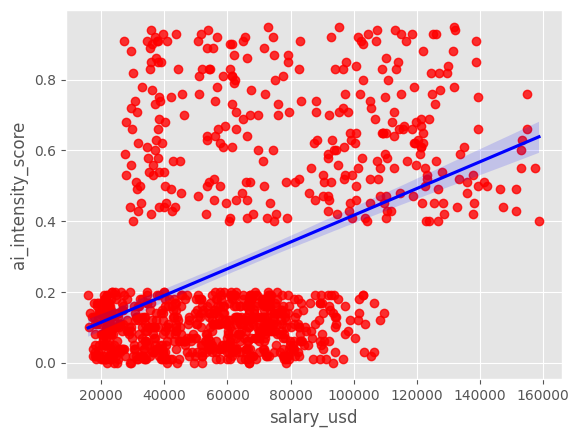

In [11]:
sns.regplot(x='salary_usd', y='ai_intensity_score', data=data, scatter_kws={"color":"red"}, line_kws={"color":"blue"})

In [ ]:
##

In [11]:
print("Correlation between salary and automation risk score:", data['salary_usd'].corr(data['automation_risk_score']))

Correlation between salary and automation risk score: -0.45032319399282184


<Axes: xlabel='salary_usd', ylabel='automation_risk_score'>

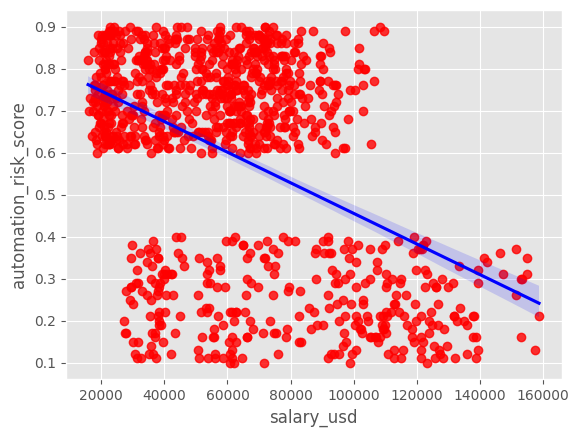

In [9]:
sns.regplot(x='salary_usd', y='automation_risk_score', data=data, scatter_kws={"color":"red"}, line_kws={"color":"blue"})

In [ ]:
##

In [9]:
print("Correlation between ai intensity score and salary change:", data['ai_intensity_score'].corr(data['salary_change_vs_prev_year_percent']))

Correlation between ai intensity score and salary change: 0.6637345921303615


<Axes: xlabel='ai_intensity_score', ylabel='salary_change_vs_prev_year_percent'>

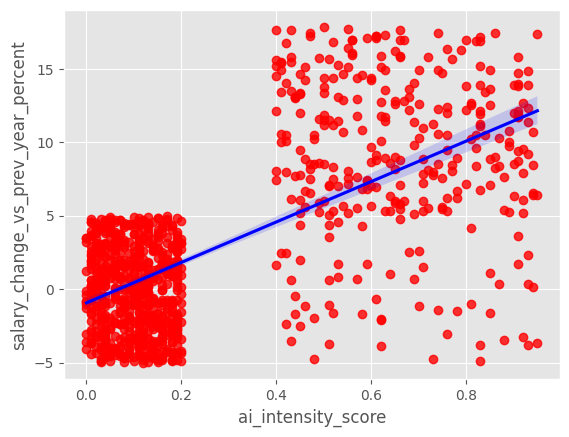

In [8]:
sns.regplot(x='ai_intensity_score', y='salary_change_vs_prev_year_percent', data=data, scatter_kws={"color":"red"}, line_kws={"color":"blue"})

In [ ]:
##

In [7]:
print("Correlation between salary and job displacement risk:", data['salary_usd'].corr(data['ai_job_displacement_risk']))

Correlation between salary and job displacement risk: 0.01586836658700572


In [25]:
print("Correlation between seniority and automation risk:", data['seniority'].corr(data['automation_risk_score']))

Correlation between seniority and automation risk: -0.021554084552539


In [7]:
print("Correlation between ai mentions and salary:", data['ai_mentioned'].corr(data['salary_usd']))

Correlation between ai mentions and salary: 0.4767176702278603


In [ ]:
##

In [10]:
data2.corr()

,posting_year,ai_intensity_score,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,job_description_embedding_cluster
posting_year,1.000000,0.449928,0.399346,0.516565,-0.468370,0.041237
ai_intensity_score,0.449928,1.000000,0.423427,0.663735,-0.871399,-0.020476
salary_usd,0.399346,0.423427,1.000000,0.389351,-0.450323,-0.025028
salary_change_vs_prev_year_percent,0.516565,0.663735,0.389351,1.000000,-0.672847,0.011947
automation_risk_score,-0.468370,-0.871399,-0.450323,-0.672847,1.000000,0.014447
job_description_embedding_cluster,0.041237,-0.020476,-0.025028,0.011947,0.014447,1.000000


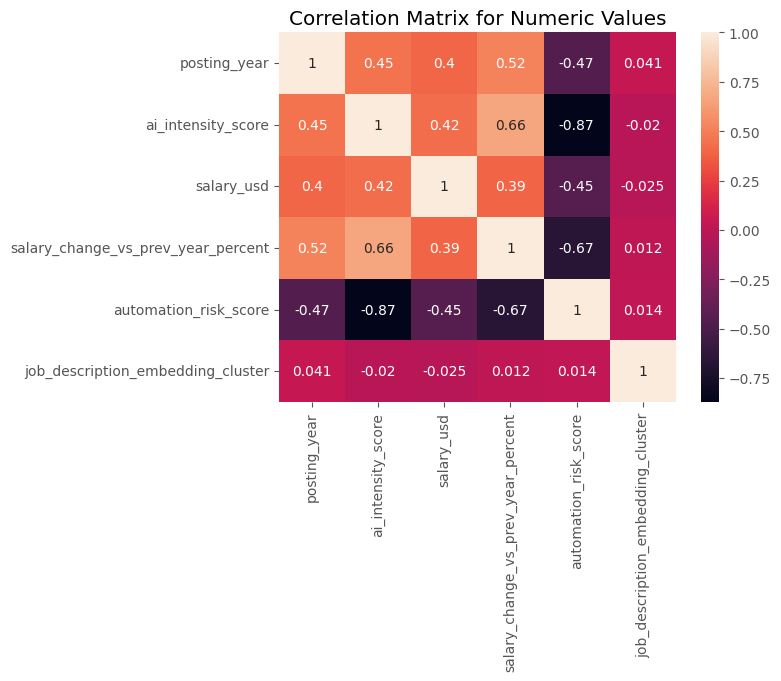

In [15]:
corr_matrix = data2.corr(method='pearson')

sns.heatmap(corr_matrix, annot = True)

plt.title("Correlation Matrix for Numeric Values")

plt.show()

In [31]:
data_numerized = data

for col_name in data_numerized.columns:
    if(data_numerized[col_name].dtype == 'object'):
        data_numerized[col_name] = data_numerized[col_name].astype('category')
        data_numerized[col_name] = data_numerized[col_name].cat.codes

data_numerized.head()

,job_id,posting_year,country,region,city,company_name,company_size,industry,job_title,seniority_level,...,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage
0,522,2010,13,8,6,0,0,2,6,2,...,0.01,878,-1,31284,-3.64,0.74,False,1,15,0
1,774,2010,15,2,9,14,3,0,2,3,...,0.19,779,-1,60960,1.97,0.64,False,1,8,0
2,692,2010,26,7,1,5,3,6,0,3,...,0.11,505,-1,21791,-3.90,0.86,False,3,13,0
3,765,2010,0,6,13,7,2,4,5,2,...,0.08,820,-1,31890,0.02,0.78,False,2,17,0
4,915,2010,2,7,2,8,3,1,0,3,...,0.02,104,-1,22997,-0.21,0.67,False,2,9,0


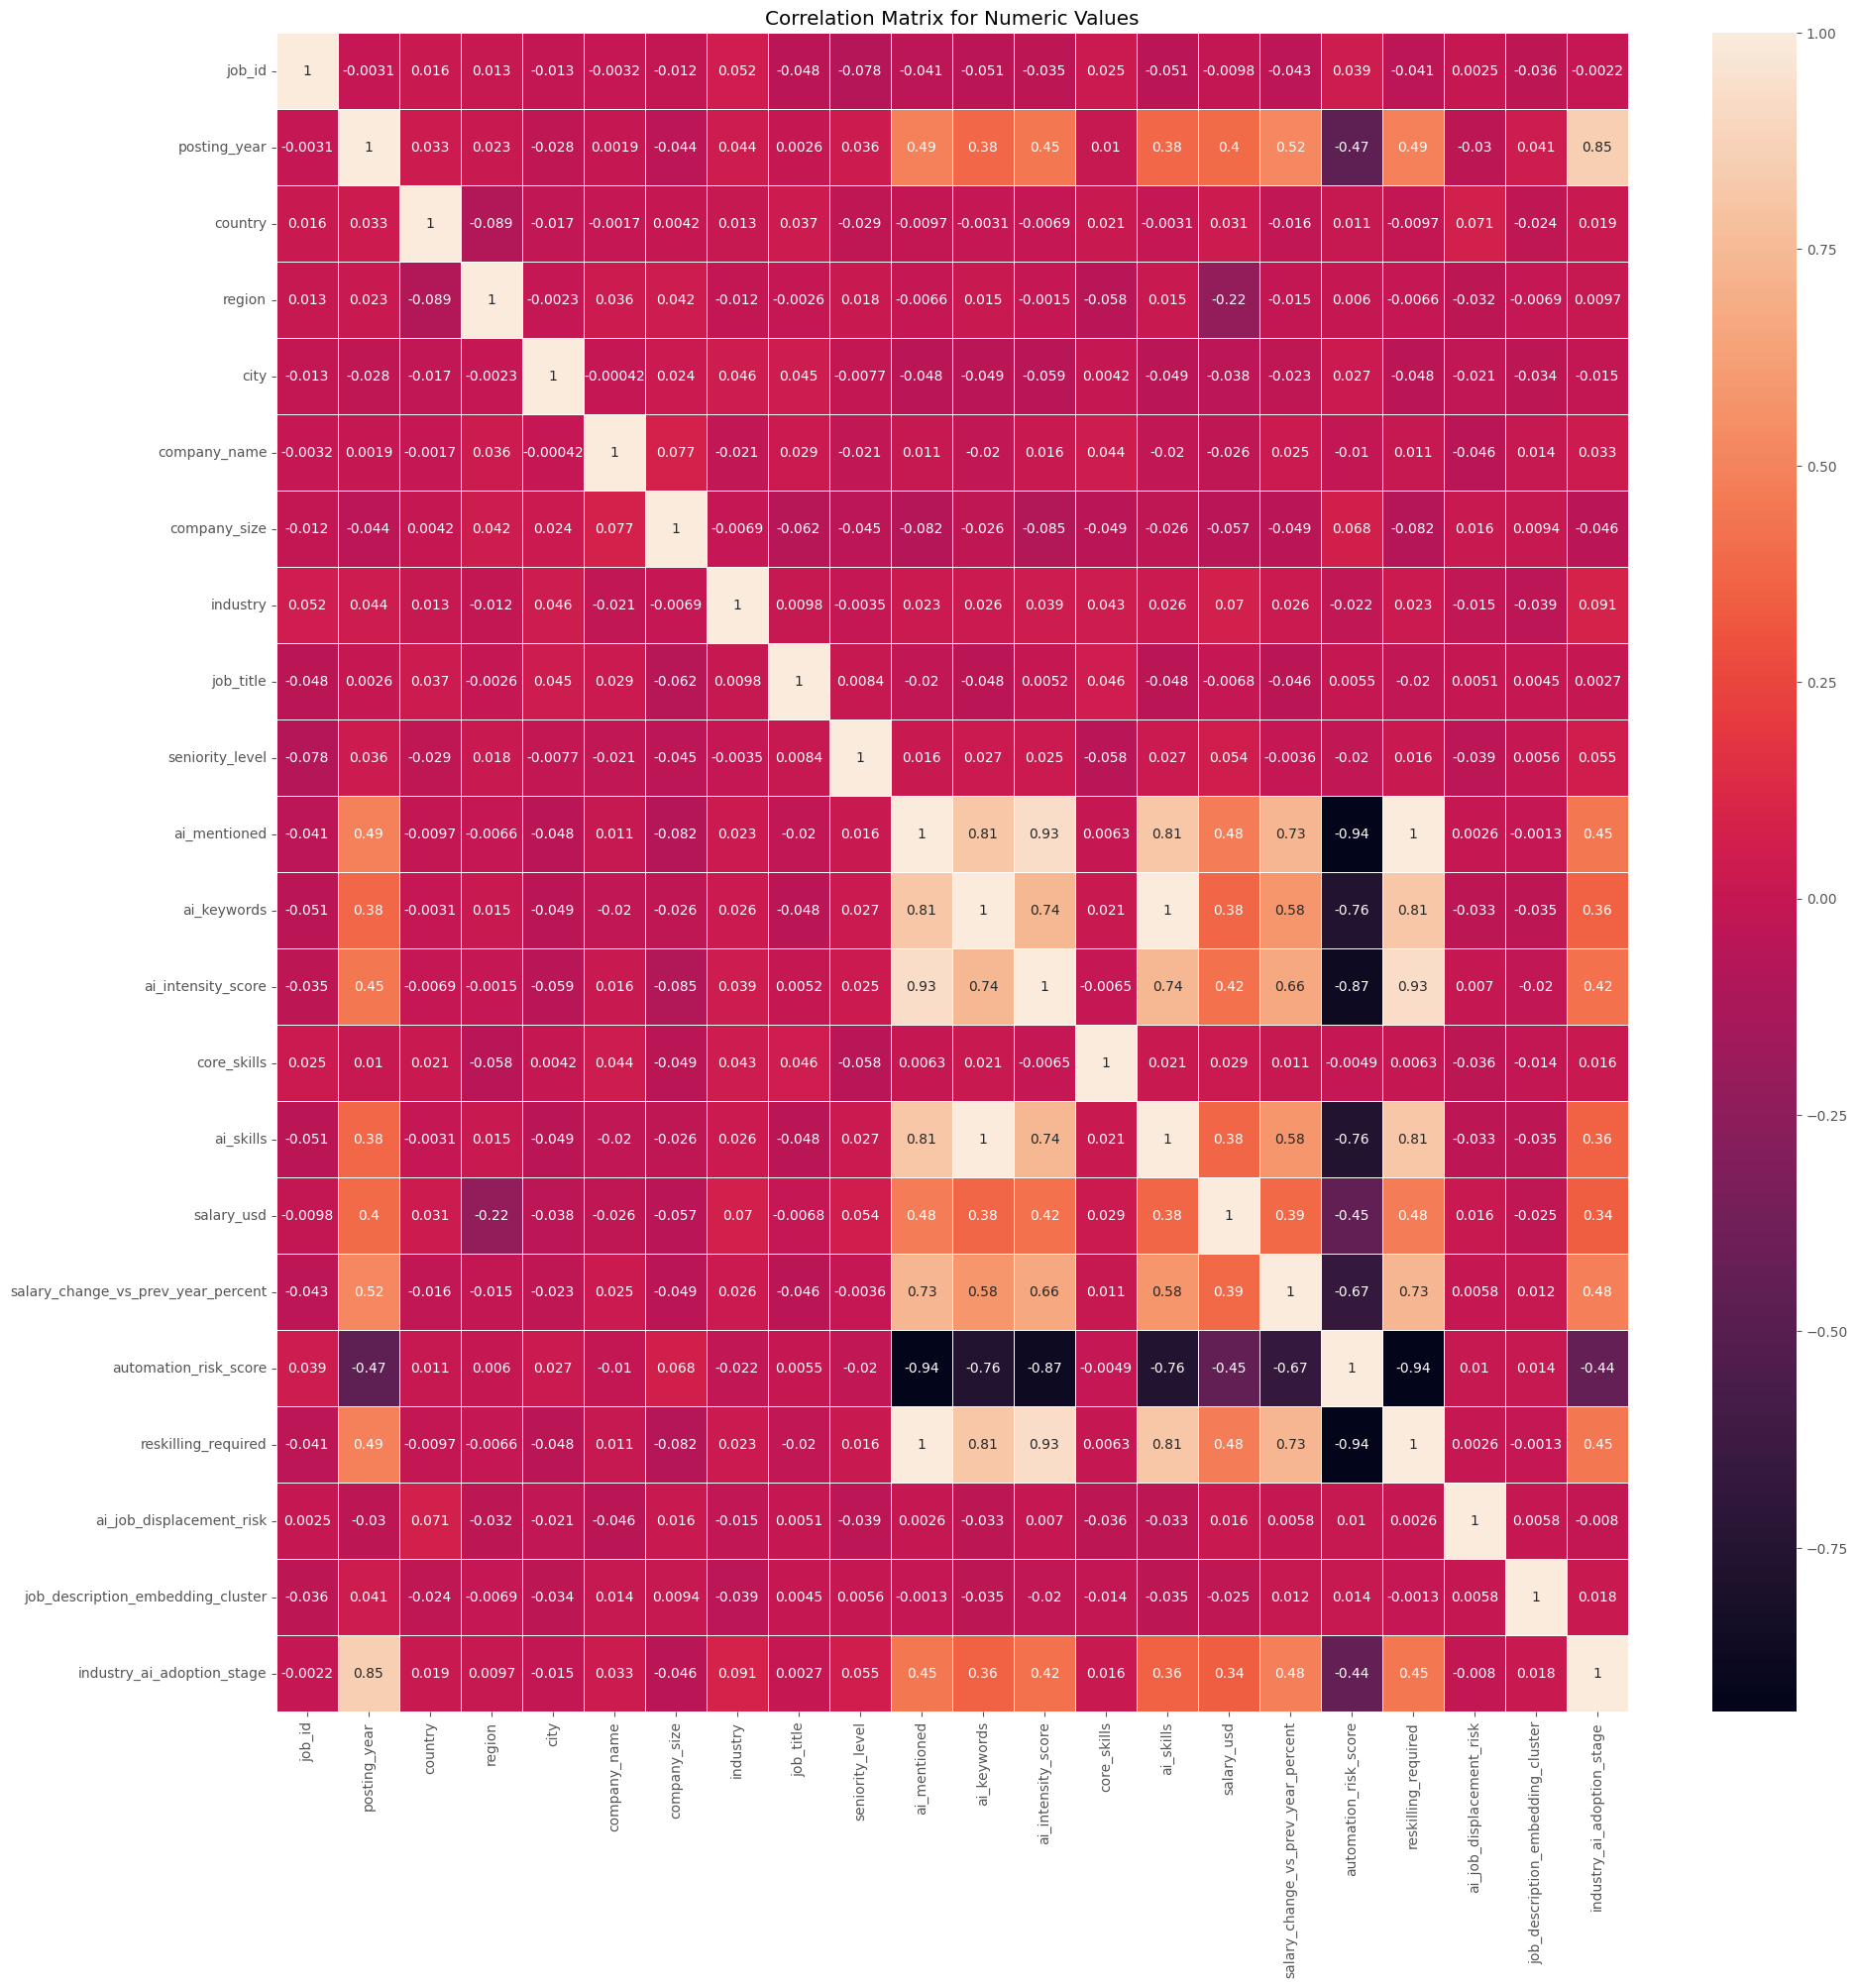

In [26]:
corr_matrix = data_numerized.corr(method='pearson')

plt.figure(figsize=(22, 22))

sns.heatmap(corr_matrix, annot = True, linewidths = 0.5)

plt.title("Correlation Matrix for Numeric Values")

plt.show()

In [30]:
corr_mat = data_numerized.corr()

corr_pairs = corr_mat.unstack()

sortedpairs = corr_pairs.sort_values()

high_corr = sortedpairs[(abs(sortedpairs)) > 0.5]

high_corr

reskilling_required                 automation_risk_score                -0.939078
automation_risk_score               reskilling_required                  -0.939078
                                    ai_mentioned                         -0.939078
ai_mentioned                        automation_risk_score                -0.939078
ai_intensity_score                  automation_risk_score                -0.871399
automation_risk_score               ai_intensity_score                   -0.871399
                                    ai_keywords                          -0.758665
ai_keywords                         automation_risk_score                -0.758665
ai_skills                           automation_risk_score                -0.758665
automation_risk_score               ai_skills                            -0.758665
                                    salary_change_vs_prev_year_percent   -0.672847
salary_change_vs_prev_year_percent  automation_risk_score                -0.672847
post

In [ ]:
# High correlation between reskilling, ai intensity score and ai mentioned